# Generate report graphs

This notebook recreates the result figures used in `main3.tex`. It writes the images to `doc/figures/` so the LaTeX report can include them directly.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# save figures beside the latex report
cwd = Path.cwd()
FIG_DIR = cwd / 'figures' if cwd.name == 'doc' else cwd / 'doc' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

## Clean 290-row text-only vs multimodal

This compares the clean balanced DialFRED/ALFRED split where both models used the same 290 matched rows.

WindowsPath('c:/Users/rfs12/OneDrive/Desktop/Computer Vision Classses/sensor-vlm/doc/figures/clean_290_text_vs_multimodal.png')

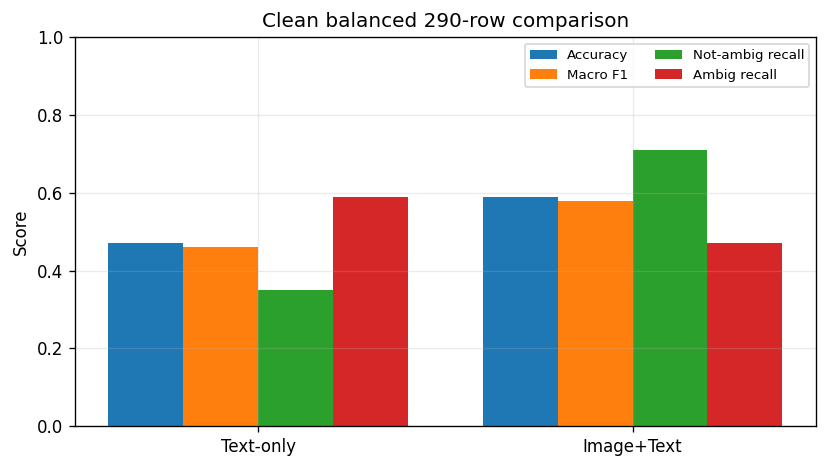

In [2]:
labels = ['Text-only', 'Image+Text']
accuracy = [0.471, 0.588]
macro_f1 = [0.46, 0.58]
not_recall = [0.35, 0.71]
amb_recall = [0.59, 0.47]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 1.5 * width, accuracy, width, label='Accuracy')
ax.bar(x - 0.5 * width, macro_f1, width, label='Macro F1')
ax.bar(x + 0.5 * width, not_recall, width, label='Not-ambig recall')
ax.bar(x + 1.5 * width, amb_recall, width, label='Ambig recall')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Clean balanced 290-row comparison')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()

output_path = FIG_DIR / 'clean_290_text_vs_multimodal.png'
fig.savefig(output_path)
output_path

## Macro-F1 across experiment variants

Macro-F1 is the fairest summary here because several larger runs are class-imbalanced.

WindowsPath('c:/Users/rfs12/OneDrive/Desktop/Computer Vision Classses/sensor-vlm/doc/figures/macro_f1_experiment_comparison.png')

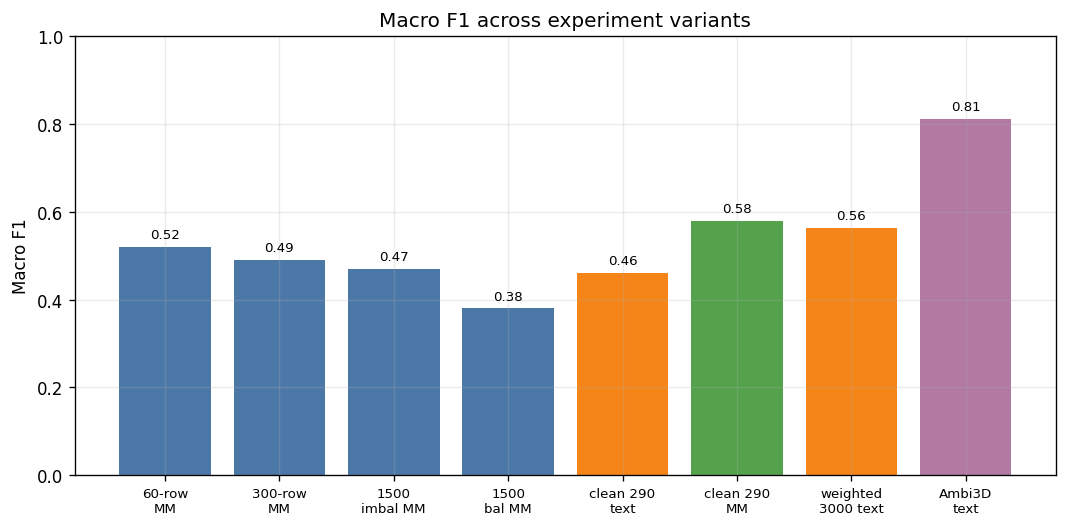

In [3]:
runs = [
    '60-row\nMM',
    '300-row\nMM',
    '1500\nimbal MM',
    '1500\nbal MM',
    'clean 290\ntext',
    'clean 290\nMM',
    'weighted\n3000 text',
    'Ambi3D\ntext',
]
# these macro-f1 values come from the saved machine reports in artifacts/reports.
macro = [0.52, 0.47, 0.47, 0.38, 0.46, 0.58, 0.563, 0.811]
colors = ['#4c78a8', '#4c78a8', '#4c78a8', '#4c78a8', '#f58518', '#54a24b', '#f58518', '#b279a2']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(np.arange(len(runs)), macro, color=colors)
ax.set_xticks(np.arange(len(runs)))
ax.set_xticklabels(runs, rotation=0, fontsize=8)
ax.set_ylim(0, 1)
ax.set_ylabel('Macro F1')
ax.set_title('Macro F1 across experiment variants')

for i, value in enumerate(macro):
    ax.text(i, value + 0.02, f'{value:.2f}', ha='center', fontsize=8)

fig.tight_layout()
output_path = FIG_DIR / 'macro_f1_experiment_comparison.png'
fig.savefig(output_path)
output_path

## Weighted 3000 text-only confusion matrix

This plot is useful for showing why high accuracy on the weighted 3000-row run is misleading.

WindowsPath('c:/Users/rfs12/OneDrive/Desktop/Computer Vision Classses/sensor-vlm/doc/figures/weighted_3000_confusion_matrix.png')

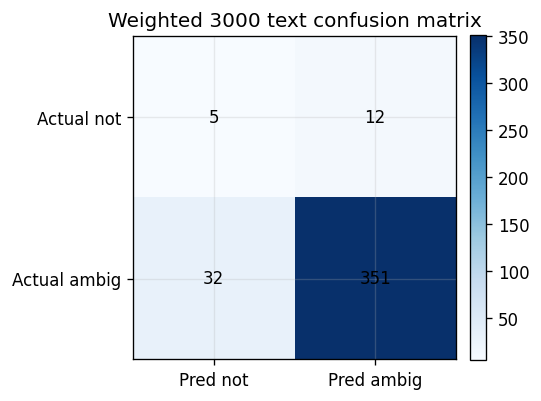

In [4]:
cm = np.array([[5, 12], [32, 351]])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred not', 'Pred ambig'])
ax.set_yticklabels(['Actual not', 'Actual ambig'])
ax.set_title('Weighted 3000 text confusion matrix')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
output_path = FIG_DIR / 'weighted_3000_confusion_matrix.png'
fig.savefig(output_path)
output_path